<a href="https://colab.research.google.com/github/manuela1702/forestfires_filledgt/blob/main/forestfires_filledgt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import math
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/forestfires_filledgt.csv')

# Display first 5 rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.972242,11.922166
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.491960,46.074340
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.408359,49.051666
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.200000,68.903192
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.392471,33.988382


In [12]:
# Rename columns to more descriptive names
df_reg = df.rename(columns={
    "temp": "temperature",
    "RH": "humidity",
    "wind": "wind_speed",
    "rain": "rainfall",
    "area": "burned_area"
})

df_reg.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temperature,humidity,wind_speed,rainfall,burned_area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.972242,11.922166
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.491960,46.074340
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.408359,49.051666
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.200000,68.903192
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.392471,33.988382


In [13]:
# Display only the columns we will analyze
df_reg[["temperature", "humidity", "wind_speed", "rainfall", "burned_area"]].head()

,temperature,humidity,wind_speed,rainfall,burned_area
0,8.2,51,6.7,0.972242,11.922166
1,18.0,33,0.9,0.491960,46.074340
2,14.6,33,1.3,0.408359,49.051666
3,8.3,97,4.0,0.200000,68.903192
4,11.4,99,1.8,0.392471,33.988382


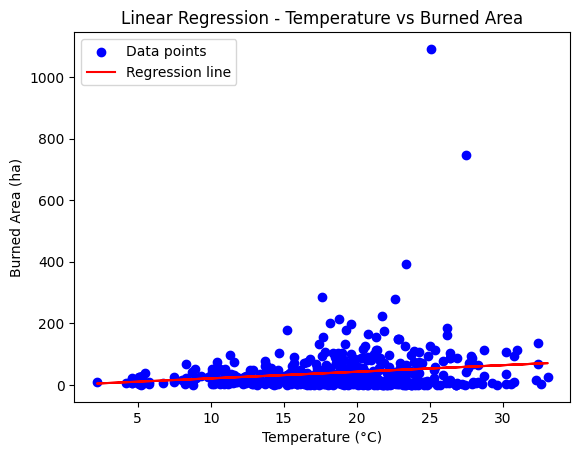

                            OLS Regression Results                            
Dep. Variable:            burned_area   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     14.52
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000156
Time:                        20:19:06   Log-Likelihood:                -2835.7
No. Observations:                 498   AIC:                             5675.
Df Residuals:                     496   BIC:                             5684.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0330     10.988     -0.003      

In [14]:
# LINEAR REGRESSION
# Define dependent and independent variables
y = df_reg["burned_area"]      # dependent variable
x = df_reg["temperature"]      # independent variable

# Add intercept constant
M1 = sm.add_constant(x)

# Fit OLS model
model1 = sm.OLS(y, M1).fit()

# Predict burned area
y_pred1 = model1.predict(M1)

# Plot data points and regression line
plt.scatter(x, y, color="blue", label="Data points")
plt.plot(x, y_pred1, color="red", label="Regression line")
plt.title("Linear Regression - Temperature vs Burned Area")
plt.xlabel("Temperature (°C)")
plt.ylabel("Burned Area (ha)")
plt.legend()
plt.show()

# Display model summary
print(model1.summary())

Linear Regression - Temperature vs Burned Area

In this section, simple linear regression was applied to examine the relationship
between temperature and burned area, using the OLS method (Ordinary Least Squares).

The goal of the analysis was to determine whether an increase in temperature
leads to an increase in the burned area.

Based on the results, the model shows statistical significance and temperature
does have an influence, however it is not sufficient on its own to fully
explain the variation in burned area.

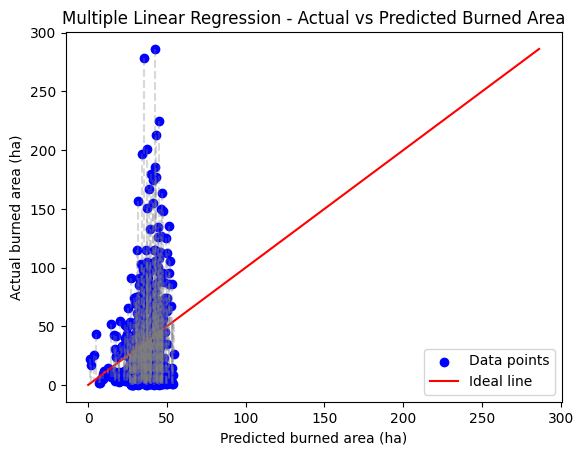

                            OLS Regression Results                            
Dep. Variable:            burned_area   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     8.449
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.75e-05
Time:                        20:19:08   Log-Likelihood:                -2551.2
No. Observations:                 495   AIC:                             5110.
Df Residuals:                     491   BIC:                             5127.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          24.4333      9.968      2.451      

In [15]:
# MULTIPLE LINEAR REGRESSION

# Filter out extreme values
df_tmp = df_reg[df_reg["burned_area"] < 300]

# Define dependent variable
y = df_tmp["burned_area"]

# Define multiple independent variables
X = df_tmp[["temperature", "rainfall", "wind_speed"]]

# Add intercept constant
M2 = sm.add_constant(X)

# Fit OLS model
model2 = sm.OLS(y, M2).fit()

# Predict burned area
y_pred2 = model2.predict(M2)

# Plot actual vs predicted burned area
plt.scatter(y_pred2, y, color="blue", label="Data points")

# Plot perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color="red", label="Ideal line")

# Plot residuals - prediction errors
for i in range(len(y)):
    plt.plot([y_pred2.iloc[i], y_pred2.iloc[i]],
             [y.iloc[i], y_pred2.iloc[i]],
             color="gray", linestyle="--", alpha=0.3)

plt.title("Multiple Linear Regression - Actual vs Predicted Burned Area")
plt.xlabel("Predicted burned area (ha)")
plt.ylabel("Actual burned area (ha)")
plt.legend()
plt.show()

# Display model summary
print(model2.summary())

Multiple Linear Regression - Temperature, Rainfall and Wind vs Burned Area

In this section, multiple linear regression was applied to examine the combined
influence of several factors on the burned area. Extreme values were first removed
from the dataset to improve model accuracy.

Using the OLS method, the model predicts the burned area based on three independent
variables: temperature, rainfall, and wind speed. This approach allows us to see
how each factor individually contributes to the burned area, and whether combining
multiple factors produces a better model compared to simple linear regression.

Based on the results, this model outperforms the previous one. Temperature has a
positive effect on burned area, rainfall has a strong negative effect, while wind
speed does not show statistically significant influence in this model.

The model is statistically significant and the additional factors contribute to
explaining the burned area, however they are not the only key factors that
determine fire spread.

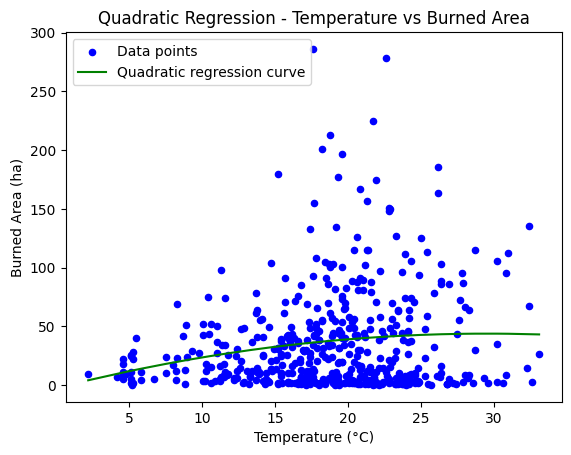

                            OLS Regression Results                            
Dep. Variable:            burned_area   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     8.040
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           0.000366
Time:                        20:19:08   Log-Likelihood:                -2555.7
No. Observations:                 495   AIC:                             5117.
Df Residuals:                     492   BIC:                             5130.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6014     13.047     -0.199      0.8

In [16]:
# QUADRATIC REGRESSION

x = df_tmp["temperature"]
y = df_tmp["burned_area"]

# Square the temperature variable
x2 = x**2

# Build matrix for quadratic regression
X_quad = pd.DataFrame({
    "const": 1,
    "x": x,
    "x2": x2
})

# Fit OLS model
model_quad = sm.OLS(y, X_quad).fit()
y_pred_quad = model_quad.predict(X_quad)

# Sort by index for smooth curve plotting
idx = np.argsort(x)
x_sorted = x.iloc[idx]
y_pred_sorted = y_pred_quad.iloc[idx]

# Plot data points and quadratic regression curve
plt.scatter(x, y, color="blue", s=20, label="Data points")
plt.plot(x_sorted, y_pred_sorted, "g-", label="Quadratic regression curve")

plt.title("Quadratic Regression - Temperature vs Burned Area")
plt.xlabel("Temperature (°C)")
plt.ylabel("Burned Area (ha)")
plt.legend()
plt.show()

# Display model summary
print(model_quad.summary())

Quadratic Regression - Temperature vs Burned Area

Quadratic regression was applied to determine whether the relationship between
temperature and burned area follows a non-linear pattern. The model includes
both temperature and its squared value, allowing for a curved relationship
between the variables.

However, the results show that the quadratic term is not statistically significant,
meaning there is not sufficient evidence to conclude that the relationship is
non-linear.

Although the model is statistically significant as a whole, temperature alone
is not a sufficient factor for accurately predicting the burned area.